# Problem Title - Baseline Linear Regression with core metrics
Issue: #6

In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('../dataset.csv')

In [8]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [9]:
y=df[['Concrete compressive strength']]
X=df.drop('Concrete compressive strength', axis=1).values

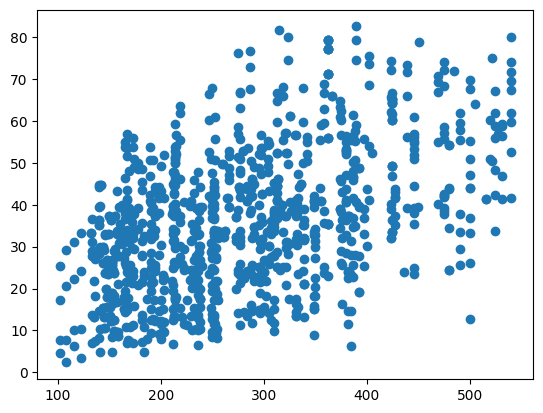

In [10]:
plt.scatter(X[:,0], y)

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [15]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
model.predict(X_test)

array([[59.65804162],
       [52.0412113 ],
       [63.53513339],
       [51.57545676],
       [17.22001733],
       [39.86561321],
       [26.6982471 ],
       [44.73648869],
       [29.36619785],
       [38.18612542],
       [27.76438338],
       [19.81055461],
       [66.8940356 ],
       [52.28562112],
       [29.96928612],
       [44.45926401],
       [29.2284856 ],
       [26.53340084],
       [31.98162681],
       [32.03208356],
       [36.82327256],
       [31.77175527],
       [38.07286862],
       [25.12353728],
       [33.0993284 ],
       [33.85670933],
       [14.24140345],
       [40.33250901],
       [41.88282591],
       [21.33261142],
       [35.71648095],
       [30.96693001],
       [43.87446203],
       [45.52648807],
       [30.7629146 ],
       [29.59299935],
       [28.90650584],
       [38.85005738],
       [20.34631763],
       [38.45267413],
       [21.16537625],
       [15.88280149],
       [31.06077771],
       [50.70684031],
       [20.26957631],
       [57

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [18]:
mean_absolute_error(y_test, model.predict(X_test))

7.745559243921434

In [19]:
mean_squared_error(y_test, model.predict(X_test))

95.97094009110681

In [20]:
r2_score(y_test, model.predict(X_test))

0.627553179231485

## Interpretation
Among the preprocessing steps, the handling of feature scaling (or lack of it) had the biggest impact on the model’s performance. Since Linear Regression is sensitive to the scale of input features, not applying normalization or standardization can lead to suboptimal performance.The train and test metrics both show high MAE, MSE, RMSE errors values and low R² scores, indicating that the model is underfitting the data. This suggests that the model is too simple to capture the underlying relationships between the features and the target variable.
The choice of using a basic Linear Regression model without any regularization or feature engineering had the most significant impact on the results. Linear Regression assumes a linear relationship between input features and the target, which may not hold true for this dataset